# Outlier Analysis

# Import Libraries and dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
scout_car = pd.read_csv('Step 2 - Nulls filled v2.csv')
scout_car

,make_model,Body Type,Price,KM,Registration,Horsepower (kW),Type,Previous Owners,Inspection new,Warranty (months),...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights
0,Audi A1,Sedans,15770,56013.0,2016.0,66.0,Used,2,1,0.0,...,0,0,1,1,0,1,1,1,0,1
1,Audi A1,Sedans,14500,80000.0,2017.0,141.0,Used,0,0,0.0,...,0,0,1,1,0,1,1,1,0,1
2,Audi A1,Sedans,14640,83450.0,2016.0,85.0,Used,1,0,0.0,...,0,0,1,1,0,1,1,1,0,0
3,Audi A1,Sedans,14500,73000.0,2016.0,66.0,Used,1,0,0.0,...,0,0,1,1,0,1,1,0,0,0
4,Audi A1,Sedans,16790,16200.0,2016.0,66.0,Used,1,1,0.0,...,0,0,1,1,0,1,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15878,Renault Espace,Van,39950,10.0,2016.0,147.0,New,0,0,0.0,...,1,0,1,1,1,1,1,1,1,0
15879,Renault Espace,Van,39885,9900.0,2019.0,165.0,Used,1,0,0.0,...,1,0,1,1,0,1,1,1,1,0
15880,Renault Espace,Van,39875,15.0,2019.0,146.0,Pre-registered,1,1,0.0,...,1,0,1,1,0,1,0,1,1,0
15881,Renault Espace,Van,39700,10.0,2019.0,147.0,Pre-registered,0,0,0.0,...,0,0,1,1,0,1,1,0,1,0


# Ensure all dtypes are what we want.

In [3]:
scout_car.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15883 entries, 0 to 15882
Data columns (total 126 columns):
 #    Column                                 Dtype  
---   ------                                 -----  
 0    make_model                             object 
 1    Body Type                              object 
 2    Price                                  int64  
 3    KM                                     float64
 4    Registration                           float64
 5    Horsepower (kW)                        float64
 6    Type                                   object 
 7    Previous Owners                        int64  
 8    Inspection new                         int64  
 9    Warranty (months)                      float64
 10   Make                                   object 
 11   Model                                  object 
 12   Body Color                             object 
 13   Paint Type                             object 
 14   # of Doors                          

Nothing is an object that shouldn't be. That's a good starting point.

In [4]:
def detect_outliers_iqr(df):
    outlier_info = {}
    for col in df.select_dtypes(include=['number']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Get outlier indices
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        outlier_info[col] = {
            "num_outliers": len(outliers),
            "pct_outliers": round(len(outliers) / len(df) * 100, 2),
            "outlier_indices": outliers.index.tolist()
        }
    return pd.DataFrame(outlier_info).T


In [5]:
outlier_summary = detect_outliers_iqr(scout_car)
outlier_summary

,num_outliers,pct_outliers,outlier_indices
Price,480,3.02,"[713, 732, 3585, 3587, 3588, 3589, 3590, 3591,..."
KM,686,4.32,"[25, 34, 61, 63, 64, 328, 369, 397, 443, 465, ..."
Registration,0,0.0,[]
Horsepower (kW),383,2.41,"[3351, 3585, 3588, 3590, 3591, 3592, 3593, 359..."
Previous Owners,19,0.12,"[679, 972, 1290, 2728, 3267, 6101, 6404, 6667,..."
...,...,...,...
Side airbag,2682,16.89,"[9, 18, 28, 30, 50, 53, 66, 67, 69, 76, 115, 1..."
Tire pressure monitoring system,0,0.0,[]
Traction control,0,0.0,[]
Traffic sign recognition,1976,12.44,"[165, 446, 447, 506, 597, 602, 737, 1280, 1648..."


# Let's have a look at these outliers.

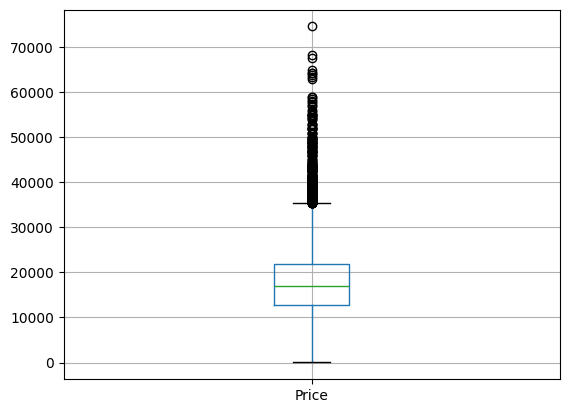

In [6]:
scout_car.boxplot(column='Price')
plt.show()

In [7]:
scout_car['Price'].nsmallest(10)

8592       13
8826      120
6064      255
8827      331
8825     4950
8823     4990
8824     5250
8822     5300
13768    5445
8821     5450
Name: Price, dtype: int64

This is strange. Four cars have values far outside the expected range. Let's load our original, uncleaned dataset, find these cars (index search won't work as some rows have been dropped), and find the description string. Even though we won't be using these in the final project, they could still provide insight into something like a crash or water damage may have occured.

In [8]:
orig_dataset = pd.read_csv('Validation Uncleaned.csv')
pd.set_option('display.max_colwidth', None)
lowprice = orig_dataset[orig_dataset['price'] < 4000]
lowprice[['make_model', 'price', 'description']]

,make_model,price,description
6066,Opel Astra,255,[]
8594,Opel Corsa,13,[]
8828,Opel Corsa,120,"['\nOpel Bestaat 120 jaar en trakteert! €120 PER MAAND. Wat koop je daarvoor? Veel, heel veel. Vijf deuren, Hill Start Assist, Cruise Control, airco, elektrisch bedienbare ramen en buitenspiegels en natuurlijk Duitse kwaliteit. En dat voor €120 per maand. Het feest is compleet! De Corsa voor €120 per maand is verkrijgbaar in negen verschillende kleuren. Optioneel verkrijgbaar met het 120 Jaar Edition +pakket (LP5M). De vanafprijs voor een 120 Jaar Edition Corsa bedraagt €19.599,- inclusief btw. Vraag naar alle informatie en voorwaarden bij onze verkoopadviseurs via info@janssenvankouwen.nl of bel 085-0530030.', 'Aanvullende specificaties', 'Laadvermogen: ', '581 kg', 'GVW: ', '1.680 kg', 'Max. trekgewicht: ', '1.200 kg', 'Afmetingen (LxBxH): ', '402 x 177 x 148 cm', 'Wielbasis: ', '251 cm', 'Fabrieksgarantie tot: ', '16-01-2021', 'Motorrijtuigenbelasting: ', '€ 116 - 130 per kwartaal', 'Aanvullende opties en accessoires', '3-spaaks lederen stuurwiel met stuurwielbediening', '3de hoofdsteun achter', ""7'' kleuren Touchscreen"", 'Airbag bestuurder en passagier, zijairbags in de voorste stoelen en gordijnairbags', 'Automatisch dimmende binnenspiegel', 'Bandenreparatieset', 'Bluetooth telefoon integratie, Audiostreaming, Apple Carplay support, USB-aansluiting', 'Centrale deurvergrendeling met afstandsbediening', 'City Mode Driving Button', 'Cruise Control met snelheidsbegrenzer', 'Deurgrepen in carrosseriekleur', 'Elektrisch verstelbaar en verwarmbare buitenspiegels, deels in carrosseriekleur', 'Getinte zijruiten en achteruit', 'Gordelspanners vóór', 'Grafisch info display', 'Halogeen koplampen', 'In hoogte en diepte verstelbaar stuurwiel', 'In hoogte verstelbare bestuurders- en passagiersstoel', 'In lengterichting verstelbare passagiersstoel', 'ISOFIX bevestigingspunten achter', 'Navi 4.0 IntelliLink - geïntegreerd navigatiesysteem met Europese kaarten', 'Park Pilot achter', 'Standaard lak', 'Twee inklapbare sleutels', 'Uitschakelbare passagiersairbag', 'Verlichting in bagageruimte', 'Verstelbare en gedeelde achterbankleuning (60/40)', 'Verstelbare en in delen neerklapbare achterbank (60/40)', 'Waarschuwing veiligheidsgordels op alle zitplaatsen', 'Zonneklep met spiegel bestuurder', 'Zwarte omlijsting rondom de zijramen', '\n']"
8829,Opel Corsa,331,"['\nOpel heeft – Bepaal ’t Zelf Lease.', 'Dat is Private Leasen en heel veel zelf bepalen.', 'Of je je huidige auto inruilt voor cash, of niet…', 'Of je je kilometers naar boven bijstelt, of juist naar beneden…', 'Of alleen jij erin rijdt… Of ook de buren.', 'En echt alle kosten zijn inbegrepen.', 'Zelfs de benzine!', 'Want Opel trakteert ook nog eens op 120 euro gratis brandstof.', 'Bekijk de actietarieven op opel.nl en bespaar deze maand tot 1800 euro op je totale lease bedrag!', '*Actie op basis van 60 maand bij 10.000km', 'Aanvullende specificaties', 'Modeljaar: ', '2019', 'Fabrieksgarantie: ', 'Ja', 'Motorrijtuigenbelasting: ', '€ 138 - 154 per kwartaal', 'Aanvullende opties en accessoires', 'Achterbank neerklapbaar (ongelijke delen)', 'Afdekscherm bagageruimte', 'Airbags voor', 'Audiobediening op het stuur', 'Automatisch dimmende binnenspiegel', 'Bestuurdersstoel in hoogte verstelbaar', 'Buitenspiegels in carrosseriekleur', 'Buitentemperatuurmeter', 'Bumpers in carrosseriekleur', 'Centrale deurvergrendeling afstandbediend', 'Elektrisch bedienbare ramen voor en achter', 'Fabrieksgarantie', 'Getint glas', 'Hoofdsteunen achter', 'In hoogte verstelbaar stuur', 'Sideskirts', 'Snelheidsbegrenzer', 'Sportstuur', 'Stoelverwarming voor', 'Telefoon', 'Toerenteller', '\n']"


I translated these descriptions and found no hints. Plus two of these have no descriptions at all. Let's just set these prices to the median for the car's make_model.

In [9]:
# Replace values under 4000 with the median Price value for each make_model
scout_car["Price"] = (
    scout_car.groupby("make_model")["Price"]
             .transform(lambda x: x.mask((x < 4000) | x.isna(), x.median()))
)

In [10]:
pd.reset_option("display.max_colwidth")

In [76]:
scout_car['Price'].nsmallest(10)

8825     4950.0
8824     5250.0
8822     5300.0
13768    5445.0
8821     5450.0
8820     5490.0
8818     5499.0
3233     5555.0
8819     5600.0
13761    5700.0
Name: Price, dtype: float64

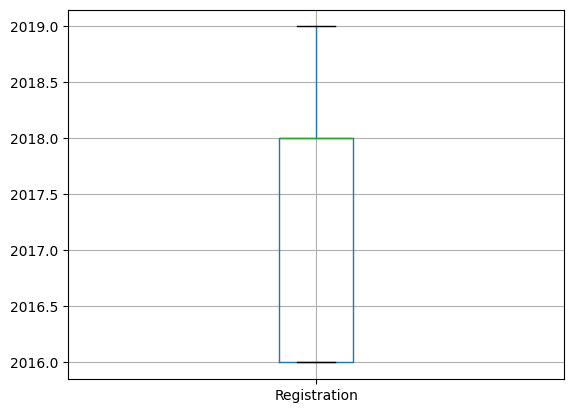

In [11]:
scout_car.boxplot(column='Registration')
plt.show()

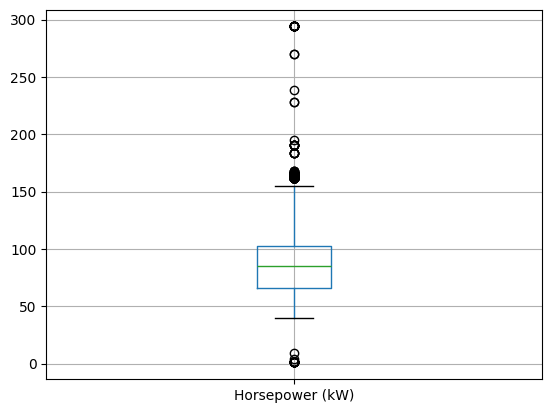

In [12]:
scout_car.boxplot(column='Horsepower (kW)')
plt.show()

Suspiciously low. Let's replace these values with the median for each car's make_model.

In [13]:
# Replace values under 50 with the median Horsepower value for each make_model
scout_car["Horsepower (kW)"] = (
    scout_car.groupby("make_model")["Horsepower (kW)"]
             .transform(lambda x: x.mask((x < 50) | x.isna(), x.median()))
)

In [14]:
scout_car['Type'].value_counts()

Type
Used              11080
New                1633
Pre-registered     1364
Employee's car     1010
Demonstration       796
Name: count, dtype: int64

In [15]:
scout_car['Previous Owners'].value_counts()

Previous Owners
1    8293
0    6793
2     778
3      17
4       2
Name: count, dtype: int64

'Next Inspection' was here but was dropped.

In [16]:
scout_car['Inspection new'].value_counts()

Inspection new
0    11951
1     3932
Name: count, dtype: int64

In [17]:
scout_car['Warranty (months)'].value_counts()

Warranty (months)
0.0     13087
12.0     1417
24.0      552
60.0      382
36.0      223
6.0        49
72.0       44
48.0       40
3.0        14
23.0       10
18.0        7
20.0        7
25.0        5
50.0        4
16.0        4
2.0         4
34.0        3
1.0         2
11.0        2
14.0        2
45.0        2
22.0        2
21.0        2
17.0        2
46.0        2
26.0        2
13.0        2
65.0        1
33.0        1
28.0        1
15.0        1
7.0         1
19.0        1
10.0        1
56.0        1
49.0        1
47.0        1
40.0        1
Name: count, dtype: int64

In [18]:
scout_car['Body Color'].value_counts()

Body Color
Black     3949
Grey      3770
White     3498
Silver    1647
Blue      1431
Red        957
Brown      289
Green      154
Beige      108
Yellow      51
Violet      18
Bronze       6
Orange       3
Gold         2
Name: count, dtype: int64

Since there are a lot of uncommon colors, we can combine them all into "other"

In [19]:
scout_car['Body Color'] = scout_car['Body Color'].replace(['Brown', 'Green', 'Beige',  'Yellow', 'Violet', 'Bronze', 'Orange', 'Gold'], 'Other')

In [20]:
scout_car['Paint Type'].value_counts()

Paint Type
Metallic       15546
Uni/basic        331
Perl effect        6
Name: count, dtype: int64

'Body Color Original' was here but was dropped.

'Body Color Original' was here, but was dropped.

In [21]:
scout_car['# of Doors'].value_counts()

# of Doors
5.0    11751
4.0     3079
3.0      832
2.0      219
1.0        1
7.0        1
Name: count, dtype: int64

In [22]:
scout_car['# of Doors'].replace([1, 4, 7], 5, inplace=True)
scout_car['# of Doors'].replace(2, 3, inplace=True)

/var/folders/cf/4zrkk0lx1nbdx9tpklpk4jc00000gn/T/ipykernel_5989/3132555173.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  scout_car['# of Doors'].replace([1, 4, 7], 5, inplace=True)
/var/folders/cf/4zrkk0lx1nbdx9tpklpk4jc00000gn/T/ipykernel_5989/3132555173.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting va

In [23]:
scout_car['# of Doors'].value_counts()

# of Doors
5.0    14832
3.0     1051
Name: count, dtype: int64

In [24]:
scout_car['# of Seats'].value_counts()

# of Seats
5.0    14277
4.0     1125
7.0      362
2.0      116
6.0        2
3.0        1
Name: count, dtype: int64

In [25]:
scout_car['# of Seats'].replace(3, 4, inplace=True)

/var/folders/cf/4zrkk0lx1nbdx9tpklpk4jc00000gn/T/ipykernel_5989/2578757864.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  scout_car['# of Seats'].replace(3, 4, inplace=True)


In [26]:
scout_car[scout_car['# of Seats'] == 6]

,make_model,Body Type,Price,KM,Registration,Horsepower (kW),Type,Previous Owners,Inspection new,Warranty (months),...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights
582,Audi A1,Compact,13500.0,100000.0,2017.0,70.0,Used,1,0,12.0,...,0,0,0,0,0,0,0,0,0,0
15854,Renault Espace,Station wagon,42490.0,10.0,2016.0,147.0,New,0,0,0.0,...,0,0,1,1,0,1,1,0,1,0


In [27]:
scout_car.loc[582, '# of Seats'] = 4

'Model Code' was here but was dropped.

In [28]:
scout_car['Gearing Type'].value_counts()

Gearing Type
Manual            8126
Automatic         7288
Semi-automatic     469
Name: count, dtype: int64

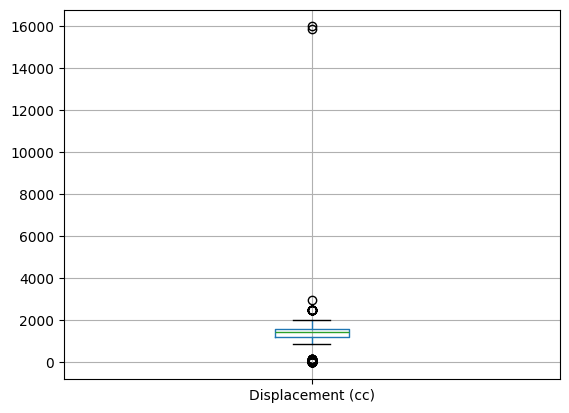

In [29]:
scout_car.boxplot(column='Displacement (cc)')
plt.show()

In [30]:
displ = (scout_car[scout_car['Displacement (cc)'] > 4000])
displ[['make_model', 'Displacement (cc)']]

,make_model,Displacement (cc)
7167,Opel Astra,15898.0
10930,Opel Insignia,16000.0


In [31]:
astra = (scout_car[scout_car['make_model'] == 'Opel Astra'])
astra['Displacement (cc)'].median()

np.float64(1399.0)

In [32]:
insignia = (scout_car[scout_car['make_model'] == 'Opel Insignia'])
insignia['Displacement (cc)'].median()

np.float64(1598.0)

In [33]:
# Replace values over 400 with the median Displacement value for each make_model
scout_car["Displacement (cc)"] = (
    scout_car.groupby("make_model")["Displacement (cc)"]
             .transform(lambda x: x.mask((x > 4000) | x.isna(), x.median()))
)

In [34]:
scout_car['Cylinders'].value_counts()

Cylinders
4.0    12890
3.0     2963
5.0       22
6.0        3
8.0        2
2.0        2
1.0        1
Name: count, dtype: int64

In [35]:
# All counts under 4, should be set to 4
scout_car['Cylinders'].replace([1, 2, 3], 4, inplace=True)

# All counts above 4 will be set to the mode for that make_model
scout_car["Cylinders"] = (
    scout_car.groupby("make_model")["Cylinders"]
             .transform(lambda x: x.mask((x < 4) | x.isna(), x.mode()))
)

/var/folders/cf/4zrkk0lx1nbdx9tpklpk4jc00000gn/T/ipykernel_5989/3698273519.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  scout_car['Cylinders'].replace([1, 2, 3], 4, inplace=True)


In [36]:
scout_car['Cylinders'].value_counts()

Cylinders
4.0    15856
5.0       22
6.0        3
8.0        2
Name: count, dtype: int64

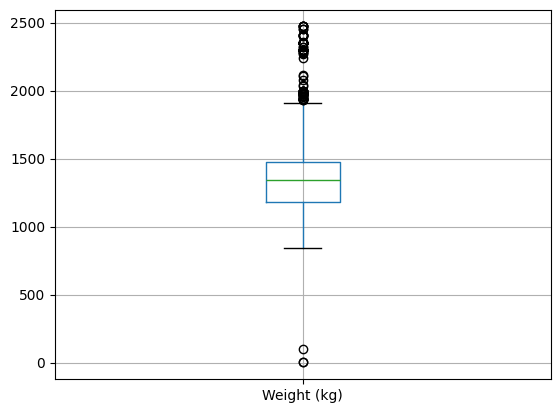

In [37]:
scout_car.boxplot(column='Weight (kg)')
plt.show()

This is strange. A few values are drastically lower than the rest. Let's see them.

In [38]:
scout_car[scout_car['Weight (kg)'] < 500]

,make_model,Body Type,Price,KM,Registration,Horsepower (kW),Type,Previous Owners,Inspection new,Warranty (months),...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights
1143,Audi A1,Compact,19229.0,8263.0,2018.0,70.0,Used,1,1,36.0,...,0,0,1,1,0,1,1,1,0,0
8353,Opel Corsa,Compact,12945.0,2015.0,2018.0,66.0,Used,1,1,0.0,...,0,0,1,1,0,1,1,1,0,0
12777,Opel Insignia,Station wagon,39299.0,10.0,2019.0,121.0,New,0,0,0.0,...,1,0,0,0,0,0,0,0,0,0


In [39]:
# Replace values under 500 with the median Weight value for each make_model
scout_car["Weight (kg)"] = (
    scout_car.groupby("make_model")["Weight (kg)"]
             .transform(lambda x: x.mask((x < 500) | x.isna(), x.median()))
)

In [40]:
# Validate this worked
scout_car[scout_car['Weight (kg)'] < 500]

,make_model,Body Type,Price,KM,Registration,Horsepower (kW),Type,Previous Owners,Inspection new,Warranty (months),...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights


In [41]:
scout_car['Drive chain'].value_counts()

Drive chain
front    15710
4WD        169
rear         4
Name: count, dtype: int64

Domain knowledge - is this likely? Leave it for now but may change later.

In [42]:
pd.set_option('display.max_rows', None)  
scout_car['Fuel'].value_counts()

Fuel
Diesel (Particulate Filter)                                                                                                       4314
Super 95                                                                                                                          3338
Gasoline                                                                                                                          3141
Diesel                                                                                                                            2983
Super 95 / Regular/Benzine 91                                                                                                      424
Regular/Benzine 91                                                                                                                 354
Super E10 95                                                                                                                       331
Super 95 (Particulate Filter)                     

In [43]:
scout_car['Fuel'].value_counts()

Fuel
Diesel (Particulate Filter)                                                                                                       4314
Super 95                                                                                                                          3338
Gasoline                                                                                                                          3141
Diesel                                                                                                                            2983
Super 95 / Regular/Benzine 91                                                                                                      424
Regular/Benzine 91                                                                                                                 354
Super E10 95                                                                                                                       331
Super 95 (Particulate Filter)                     

In [44]:
elec = scout_car[scout_car['Fuel'].str.contains('Electric')]
elec['Fuel'].value_counts()

Fuel
Electric/Gasoline    4
Electric             1
Name: count, dtype: int64

In [45]:
cng = scout_car[scout_car['Fuel'].str.contains('CNG')]
cng['Fuel'].value_counts()

Fuel
CNG                         33
CNG (Particulate Filter)     3
Name: count, dtype: int64

In [46]:
lpg = scout_car[scout_car['Fuel'].str.contains('LPG')]
lpg['Fuel'].value_counts()

Fuel
LPG                           16
Liquid petroleum gas (LPG)    10
Name: count, dtype: int64

In [47]:
scout_car['Fuel'].replace('Electric/Gasoline', 'Hybrid', inplace=True)
scout_car['Fuel'].replace('Diesel (Particular Filter)', 'Diesel', inplace=True)
scout_car['Fuel'].replace('CNG', 'Natural gas', inplace=True)
scout_car['Fuel'].replace('CNG (Particulate Filter)', 'Natural Gas', inplace=True)
scout_car['Fuel'].replace('LPG', 'Liquid petroleum gas', inplace=True)
scout_car['Fuel'].replace('Liquid petroleum gas (LPG)', 'Liquid petroleum gas', inplace=True)

# Define the unique fuel types we want to keep
fuel_types_to_keep = ['Hybrid', 'Diesel', 'Electric', 'Natural gas', 'Liquid petroleum gas']

# Replace all others with 'Gasoline and Others'
scout_car['Fuel'].mask(~scout_car['Fuel'].isin(fuel_types_to_keep), 'Gasoline and Others', inplace=True)

In [48]:
pd.reset_option('display.max_rows', None)  

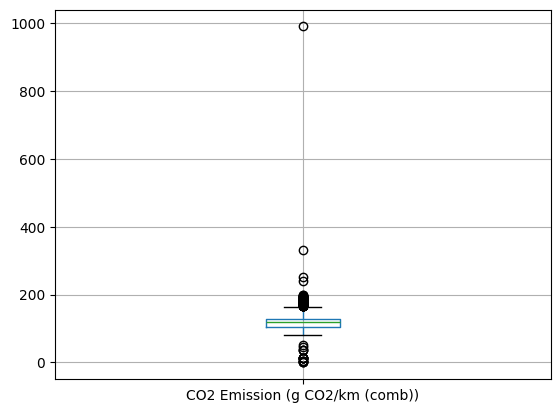

In [49]:
scout_car.boxplot(column='CO2 Emission (g CO2/km (comb))')
plt.show()

One extreme outlier. Let's see it.

In [50]:
scout_car[scout_car['CO2 Emission (g CO2/km (comb))'] > 800]

,make_model,Body Type,Price,KM,Registration,Horsepower (kW),Type,Previous Owners,Inspection new,Warranty (months),...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights
4554,Audi A3,Sedans,23500.0,27815.0,2018.0,81.0,Used,0,0,0.0,...,0,0,0,1,0,0,0,1,0,1


In [51]:
high_emission_df = scout_car[scout_car['CO2 Emission (g CO2/km (comb))'] > 800]
high_emission_df[['CO2 Emission (g CO2/km (comb))']]

,CO2 Emission (g CO2/km (comb))
4554,990.0


In [52]:
audi_a3_df = scout_car[scout_car['make_model'] == 'Audi A3']
audi_a3_df['CO2 Emission (g CO2/km (comb))'].median()

np.float64(107.0)

In [53]:
scout_car.loc[4554, 'CO2 Emission (g CO2/km (comb))'] = 107 

In [54]:
scout_car[scout_car['CO2 Emission (g CO2/km (comb))'] > 800]

,make_model,Body Type,Price,KM,Registration,Horsepower (kW),Type,Previous Owners,Inspection new,Warranty (months),...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights


In [55]:
scout_car['Emission Class'].value_counts()

Emission Class
Euro 6          13763
Euro 6d-TEMP     1845
Euro 6c           127
Euro 5             78
Euro 6d            62
Euro 4              8
Name: count, dtype: int64

In [56]:
scout_car['Emission Label'].value_counts()

Emission Label
4 (Green)         15492
1 (No sticker)      380
5 (Blue)              8
3 (Yellow)            2
2 (Red)               1
Name: count, dtype: int64

In [57]:
scout_car['Gears'].value_counts()

Gears
6.0     9326
5.0     4411
7.0     1908
8.0      224
9.0        6
1.0        2
3.0        2
4.0        2
2.0        1
50.0       1
Name: count, dtype: int64

50 gears?

In [58]:
scout_car[scout_car['Gears'] > 49]

,make_model,Body Type,Price,KM,Registration,Horsepower (kW),Type,Previous Owners,Inspection new,Warranty (months),...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights
14493,Renault Clio,Sedans,10798.0,10.0,2019.0,56.0,Pre-registered,1,0,0.0,...,0,0,1,0,0,1,1,1,0,0


In [59]:
renault_clio_df = scout_car[scout_car['make_model'] == 'Renault Clio']
renault_clio_df['Gears'].median()

np.float64(5.0)

In [60]:
scout_car.loc[14493, 'Gears'] = 5

In [61]:
scout_car[scout_car['Gears'] > 49]

,make_model,Body Type,Price,KM,Registration,Horsepower (kW),Type,Previous Owners,Inspection new,Warranty (months),...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights


In [62]:
scout_car['Country version'].value_counts()

Country version
Germany           12808
Italy              1038
European Union      507
Netherlands         464
Spain               325
Belgium             313
Austria             208
Czech Republic       52
Poland               49
France               38
Denmark              33
Hungary              28
Slovakia              4
Croatia               4
Sweden                3
Romania               2
Bulgaria              2
Luxembourg            1
Switzerland           1
Slovenia              1
Egypt                 1
Serbia                1
Name: count, dtype: int64

Several uncommon countries. I will use Hungary as our lower boundary, as Slovakia - Hungary is proportionally a bigger jump than Czech - Austria.

In [63]:
# More primitive version, hard coded
#scout_car['Country version'] = scout_car['Country version'].replace(['Slovakia', 'Croatia', 'Sweden',  'Romania', 'Bulgaria', 'Luxembourg', 'Switzerland', 'Slovenia', 'Egypt', 'Serbia'], 'Other')

In [64]:
# Find values with count < 28
counts = scout_car['Country version'].value_counts()

# Replace those with 'Other'
scout_car['Country version'] = scout_car['Country version'].where(
    scout_car['Country version'].map(counts) >= 28,
    'Other'
)

In [65]:
scout_car['Upholstery Material'].value_counts()

Upholstery Material
Cloth           11781
Part leather     1499
Full leather     1335
Black             491
Other             368
Grey              273
Velour             60
alcantara          57
Brown              12
Beige               3
Blue                2
White               2
Name: count, dtype: int64

Some of these values list a color as the material. It's possible this was a data cleaning mistake, but impossible to verify without checking every row manually. For now I will simply drop these rows.

In [66]:
wrong_materials = ['Black', 'Grey', 'Brown', 'Beige', 'Blue', 'White']
scout_car = scout_car[~scout_car['Upholstery Material'].isin(wrong_materials)]

In [67]:
scout_car['Upholstery Material'].value_counts()

Upholstery Material
Cloth           11781
Part leather     1499
Full leather     1335
Other             368
Velour             60
alcantara          57
Name: count, dtype: int64

In [68]:
scout_car['Upholstery Color'].value_counts()

Upholstery Color
Black     12769
Grey       1087
Other       959
Brown       195
Beige        51
Blue         14
White        11
Red           9
Yellow        4
Orange        1
Name: count, dtype: int64

In [69]:
# Find values with count < 28
counts = scout_car['Upholstery Color'].value_counts()

# Replace those with 'Other'
scout_car['Upholstery Color'] = scout_car['Upholstery Color'].where(
    scout_car['Upholstery Color'].map(counts) >= 195,
    'Other'
)

/var/folders/cf/4zrkk0lx1nbdx9tpklpk4jc00000gn/T/ipykernel_5989/275237872.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scout_car['Upholstery Color'] = scout_car['Upholstery Color'].where(


In [70]:
scout_car['Upholstery Color'].value_counts()

Upholstery Color
Black    12769
Grey      1087
Other     1049
Brown      195
Name: count, dtype: int64

These consumption columns each have similar amounts of outliers in similar locations. We will assume these are not misprints and leave them.

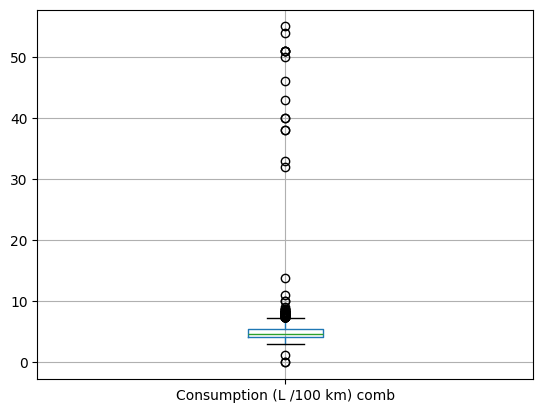

In [71]:
scout_car.boxplot(column='Consumption (L /100 km) comb')
plt.show()

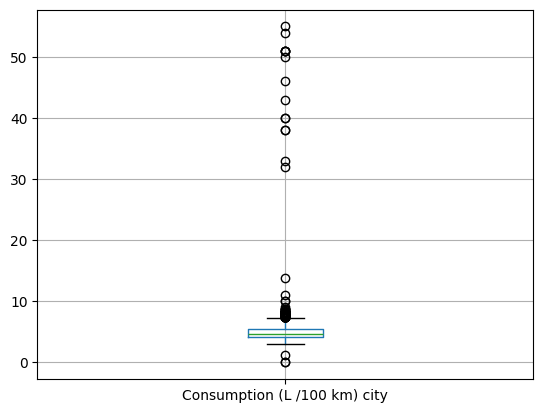

In [72]:
scout_car.boxplot(column='Consumption (L /100 km) city')
plt.show()

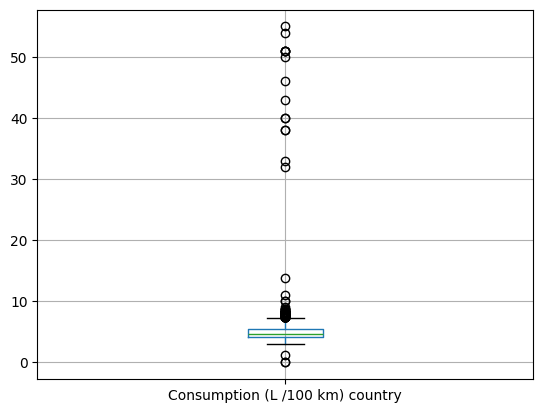

In [73]:
scout_car.boxplot(column='Consumption (L /100 km) country')
plt.show()

Comfort & Convenience, Entertainment & Media, Extras, Safety & Security each had dummies created earlier. Drop_first is not appropriate in those cases as each car may have any combination of features among these. Thus, nothing else needs to be done for these.

In [74]:
#scout_car.to_csv('Validation csv 22.csv', index=False)

In [75]:
scout_car.to_csv('Step 3 - Outliers handled.csv', index=False)